## Objective

This homework sheet will help reviewing the basic concepts associated with classification models. Please review the lectures, suggested readings, and additional resources before getting started on the HW.


**Some questions in this assignment will require you to conduct independent research beyond the material covered in the recorded content.**

**Questions**


This homework is divided into two main parts. First, a conceptual component will review the basic concepts related to classification models. The second part of the homework is mostly intended to be a brief introduction to fitting and analyzing classifiers in `Python`. Several of these questions are modified from James et al. (2021).



Marks Distribution

| Question      | Marks |
| ----------- | ----------- |
| 1a    |    0.25  |
| 1b    |    0.25   |
| 1c    |    0.25   |
| 1d     |   0.25    |
| 2a     |    0.50  |
| 2b     |    0.50  |
| 3     |     1 |
| 4a    |    1  |
| 4b    |    1   |
| 4c    |     0.5  |
| 4d     |    1   |
| 4e     |    1  |
| 4f     |    1   |
| 4g     |     0.25  |
| 4h     |     0.25  |
| 5a    |     1 |
| 5b    |     1  |
| 5c    |     1  |
| 5d     |     1  |
| 5e     |     1  |
| 5f     |     1  |

## Conceptual Questions

### Q1. Let’s examine the differences between LDA and QDA.

#### a) If the Bayes decision boundary is linear, do we expect LDA or QDA to perform better on the training set? What about in the test set?

Answer:

1. QDA is expected to perform better than LDA on the training set as it is more flexible than LDA. QDA being more flexible than LDA fits the training data well.

2. If the Bayes decision boundary is linear then LDA is expected to perform better on the test set as LDA is more generalized than QDA. QDA overfits the data because of its higher flexibility hence, LDA performs better on the test set.

#### b) If the Bayes decision boundary is non-linear, do we expect LDA or QDA to perform better on the training set? On the test set?


Answer:

1. If the Bayes decision boundary is non-linear then QDA is expected to perform better than LDA on both training and test set as it is more flexible than LDA.

2. QDA can learn the underlying non-linearity better than LDA because of its higher flexibility. Therefore, QDA not only performs better on training set but also on test set too.

3. Moreover, LDA has high bias as it is a simple model.

#### c)In general, as the sample size n increases, do we expect the test prediction accuracy of QDA relative to LDA to improve, decline, or be unchanged? Why?

Answer:

1. In general as sample size n increases, the test prediction accuracy of QDA is expected to improve relative to LDA because of decrease in the variance.

2. In case of linear Bayes decision boundary, QDA will overfit the data but this will decrease with increase in the sample size n because of decrease in the variance. So, the improve in test prediction accuracy is higher for QDA relative to LDA.

3. In case of non-linear Bayes decision boundary, QDA can learn the non-linearity better than LDA because of its higher flexibility. In addition to this, the variance also decreases with increase in the sample size n. Hence, the improve in test prediction accuracy is higher for QDA relative to LDA.

4. Therefore, in general as sample size n increases, the test prediction accuracy of QDA is expected to improve relative to LDA.

#### d)True or False:
Even if the Bayes decision boundary for a given problem is linear, we will probably achieve a superior test error rate using QDA rather than LDA because QDA is flexible enough to model a linear decision boundary.


Answer:

1. The given statement is **false**.
  
2. In case of a linear Bayes decision boundary, QDA will not achieve a superior test error rate than LDA because QDA overfits the training data because of its higher flexibility. LDA does not overfit the data and is more generalized in this scenario.

3. Hence, LDA achieves a superior test error rate than QDA. 

### Q2) In relation to the odds and the Default dataset

#### a) On average, what fraction of people with an odds of `0.37` of defaulting on their credit card payment will in fact default?


In [2]:
# BEGIN SOLUTION
odds = 0.37 # p/(1-p)

p = (odds)/(1+odds) # fraction of people
round(p,3)
# END SOLUTION


0.27

Provide answer in the markdown cell

**The fraction of people that will default on their credit card payment is 0.27**

#### b) Suppose that an individual has a `16%` chance of defaulting on their credit card payment. What are the odds that they will default?

In [3]:
# BEGIN SOLUTION
p = 0.16

odds = (p)/(1-p)

round(odds,3)

# END SOLUTION

0.19

Answer: Provide answer in the markdown cell

**The odds that they will default is 0.19**

#### Q3. Suppose that we take a data set, divide it into equally sized training and test sets, and then try out two different classification procedures. First, we use logistic regression and get an error rate of `20%` on the training data and `30%` on the test data. Next we use 1-nearest neighbors (i.e. `K=1`) and get an average error rate (averaged over both test and training data sets) of `18%`. Based on these results, which method should we prefer to use for classification of new observations? Why?


Answer:Provide answer in the markdown cell

1. We select the model that has the least test error rate. Logistic regression has 30% test error rate and 1-nearest neighbour has an average error rate  of 18%(test+training).

2. The training error rate for 1-nearest neighbour is zero because the closest point to a training data observation is itself. This implies that the test error rate for 1-nearest neighbour is 36% ($\epsilon_{test} = 2*(0.18) - \epsilon_{training} = 0.36$). This model also overfits the training data.

3. Therefore, we should prefer the logistic regression method for classification of new observations.


## Applied

#### 4) This question should be answered using the `Weekly` data set, which is part of the `ISLR2` package. This data is similar in nature to the `Smarket` data examined in the book (Ch4, lab). First, load the dataset:


 https://book.huihoo.com/introduction-to-statistical-learning/data.html

 Link for getting rdataset into python:
 https://www.statsmodels.org/dev/datasets/statsmodels.datasets.get_rdataset.html


 By using the below command you can get the ISLR dataset
 `sm.datasets.get_rdataset('Weekly', 'ISLR').data`

#### a) Produce some numerical and graphical summaries of the `Weekly` data. Can you identify any patterns? Hint: examine the __correlation__ between predictors.

**Importing Libraries:**

In [18]:
#IMPORT LIBRARIES
import statsmodels.api as sm
import statsmodels.formula.api as smf
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, confusion_matrix, accuracy_score, ConfusionMatrixDisplay
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

**Loading dataset:**

In [19]:
#READ Weekly DATASET USING THE CODE GIVEN IN QUESTION 4

org = sm.datasets.get_rdataset('Weekly', 'ISLR').data
org.info()
org.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   object 
dtypes: float64(7), int64(1), object(1)
memory usage: 76.7+ KB


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,Down
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,Down
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,Up
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,Up
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,Up


In [20]:
#PERFORM PRE PROCESSING OF DATA IF REQUIRED ( OBSERVE THE DATASET AND ITS VALUES CAREFULLY)
df = org.copy()
df['Direction'] = df['Direction'].map({'Up':1,'Down':0})
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1089 entries, 0 to 1088
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Year       1089 non-null   int64  
 1   Lag1       1089 non-null   float64
 2   Lag2       1089 non-null   float64
 3   Lag3       1089 non-null   float64
 4   Lag4       1089 non-null   float64
 5   Lag5       1089 non-null   float64
 6   Volume     1089 non-null   float64
 7   Today      1089 non-null   float64
 8   Direction  1089 non-null   int64  
dtypes: float64(7), int64(2)
memory usage: 76.7 KB


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
0,1990,0.816,1.572,-3.936,-0.229,-3.484,0.154976,-0.270,0
1,1990,-0.270,0.816,1.572,-3.936,-0.229,0.148574,-2.576,0
2,1990,-2.576,-0.270,0.816,1.572,-3.936,0.159837,3.514,1
3,1990,3.514,-2.576,-0.270,0.816,1.572,0.161630,0.712,1
4,1990,0.712,3.514,-2.576,-0.270,0.816,0.153728,1.178,1


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
Year,1.000000,-0.032289,-0.033390,-0.030006,-0.031128,-0.030519,0.841942,-0.032460,-0.022200
Lag1,-0.032289,1.000000,-0.074853,0.058636,-0.071274,-0.008183,-0.064951,-0.075032,-0.050004
Lag2,-0.033390,-0.074853,1.000000,-0.075721,0.058382,-0.072499,-0.085513,0.059167,0.072696
Lag3,-0.030006,0.058636,-0.075721,1.000000,-0.075396,0.060657,-0.069288,-0.071244,-0.022913
Lag4,-0.031128,-0.071274,0.058382,-0.075396,1.000000,-0.075675,-0.061075,-0.007826,-0.020549
Lag5,-0.030519,-0.008183,-0.072499,0.060657,-0.075675,1.000000,-0.058517,0.011013,-0.018168
Volume,0.841942,-0.064951,-0.085513,-0.069288,-0.061075,-0.058517,1.000000,-0.033078,-0.017995
Today,-0.032460,-0.075032,0.059167,-0.071244,-0.007826,0.011013,-0.033078,1.000000,0.720025
Direction,-0.022200,-0.050004,0.072696,-0.022913,-0.020549,-0.018168,-0.017995,0.720025,1.000000


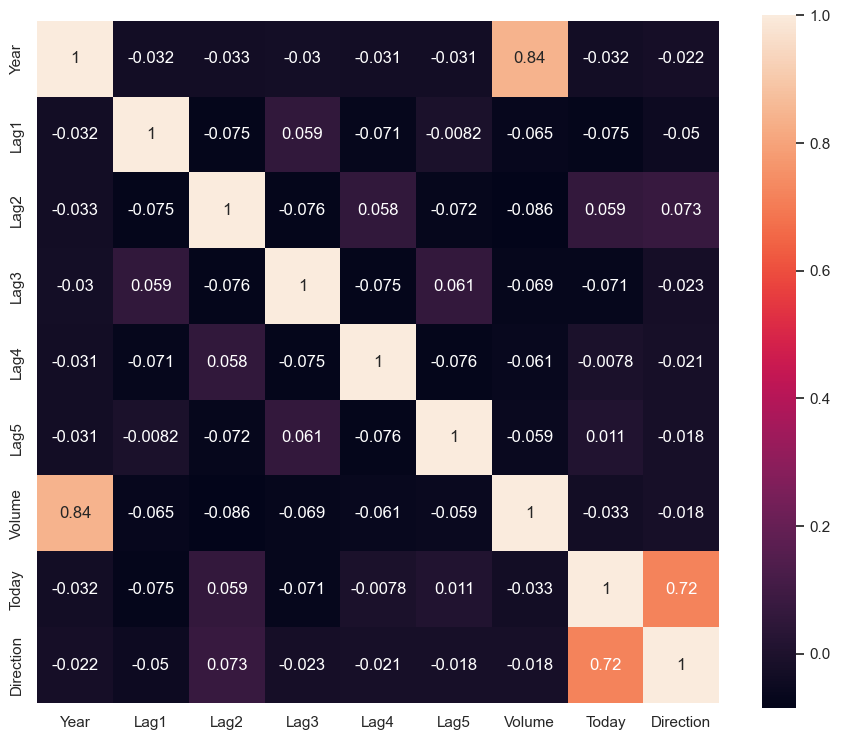

In [21]:
# BEGIN SOLUTION
# Numerical summaries

correlation_matrix = df.corr()
f,ax = plt.subplots(figsize=(11,9))
sns.heatmap(correlation_matrix,annot=True,square=True)
(correlation_matrix)

# END SOLUTION

**From the above correlation heatmap it is clear that there is a strong correlation between year and volume, and, today and direction.**

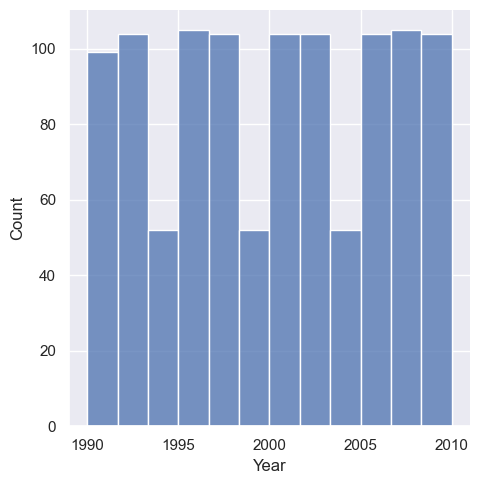

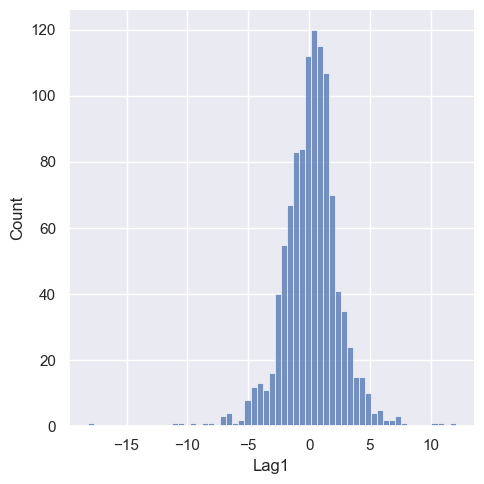

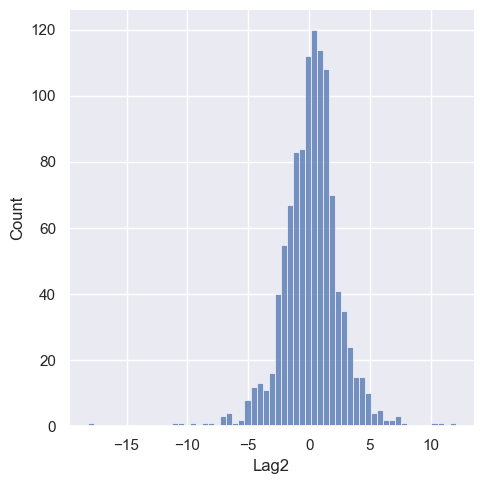

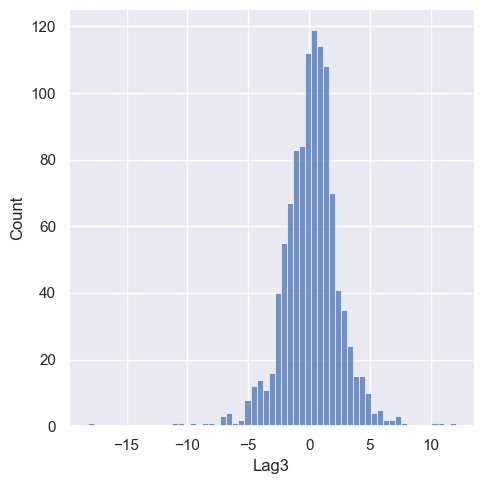

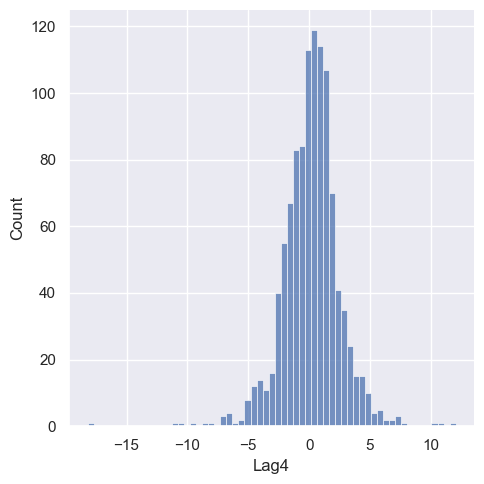

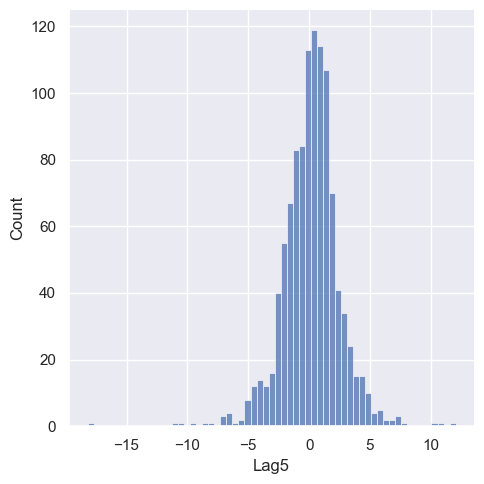

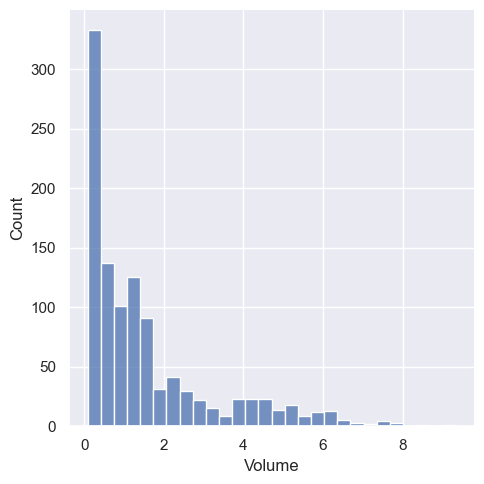

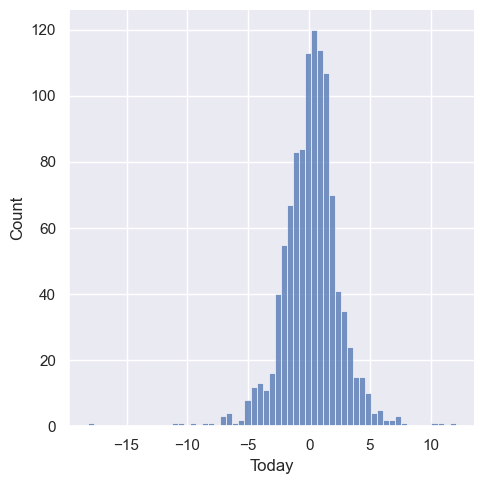

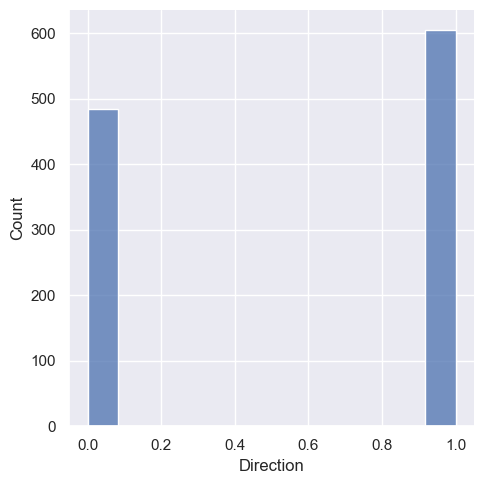

In [24]:
# BEGIN SOLUTION

for col in df.columns:
    sns.displot(df,x=col)

# END SOLUTION

**The response 'Direction' is not biased towards any single class. The count of both 0('Down') and 1('Up') are not too far apart.**

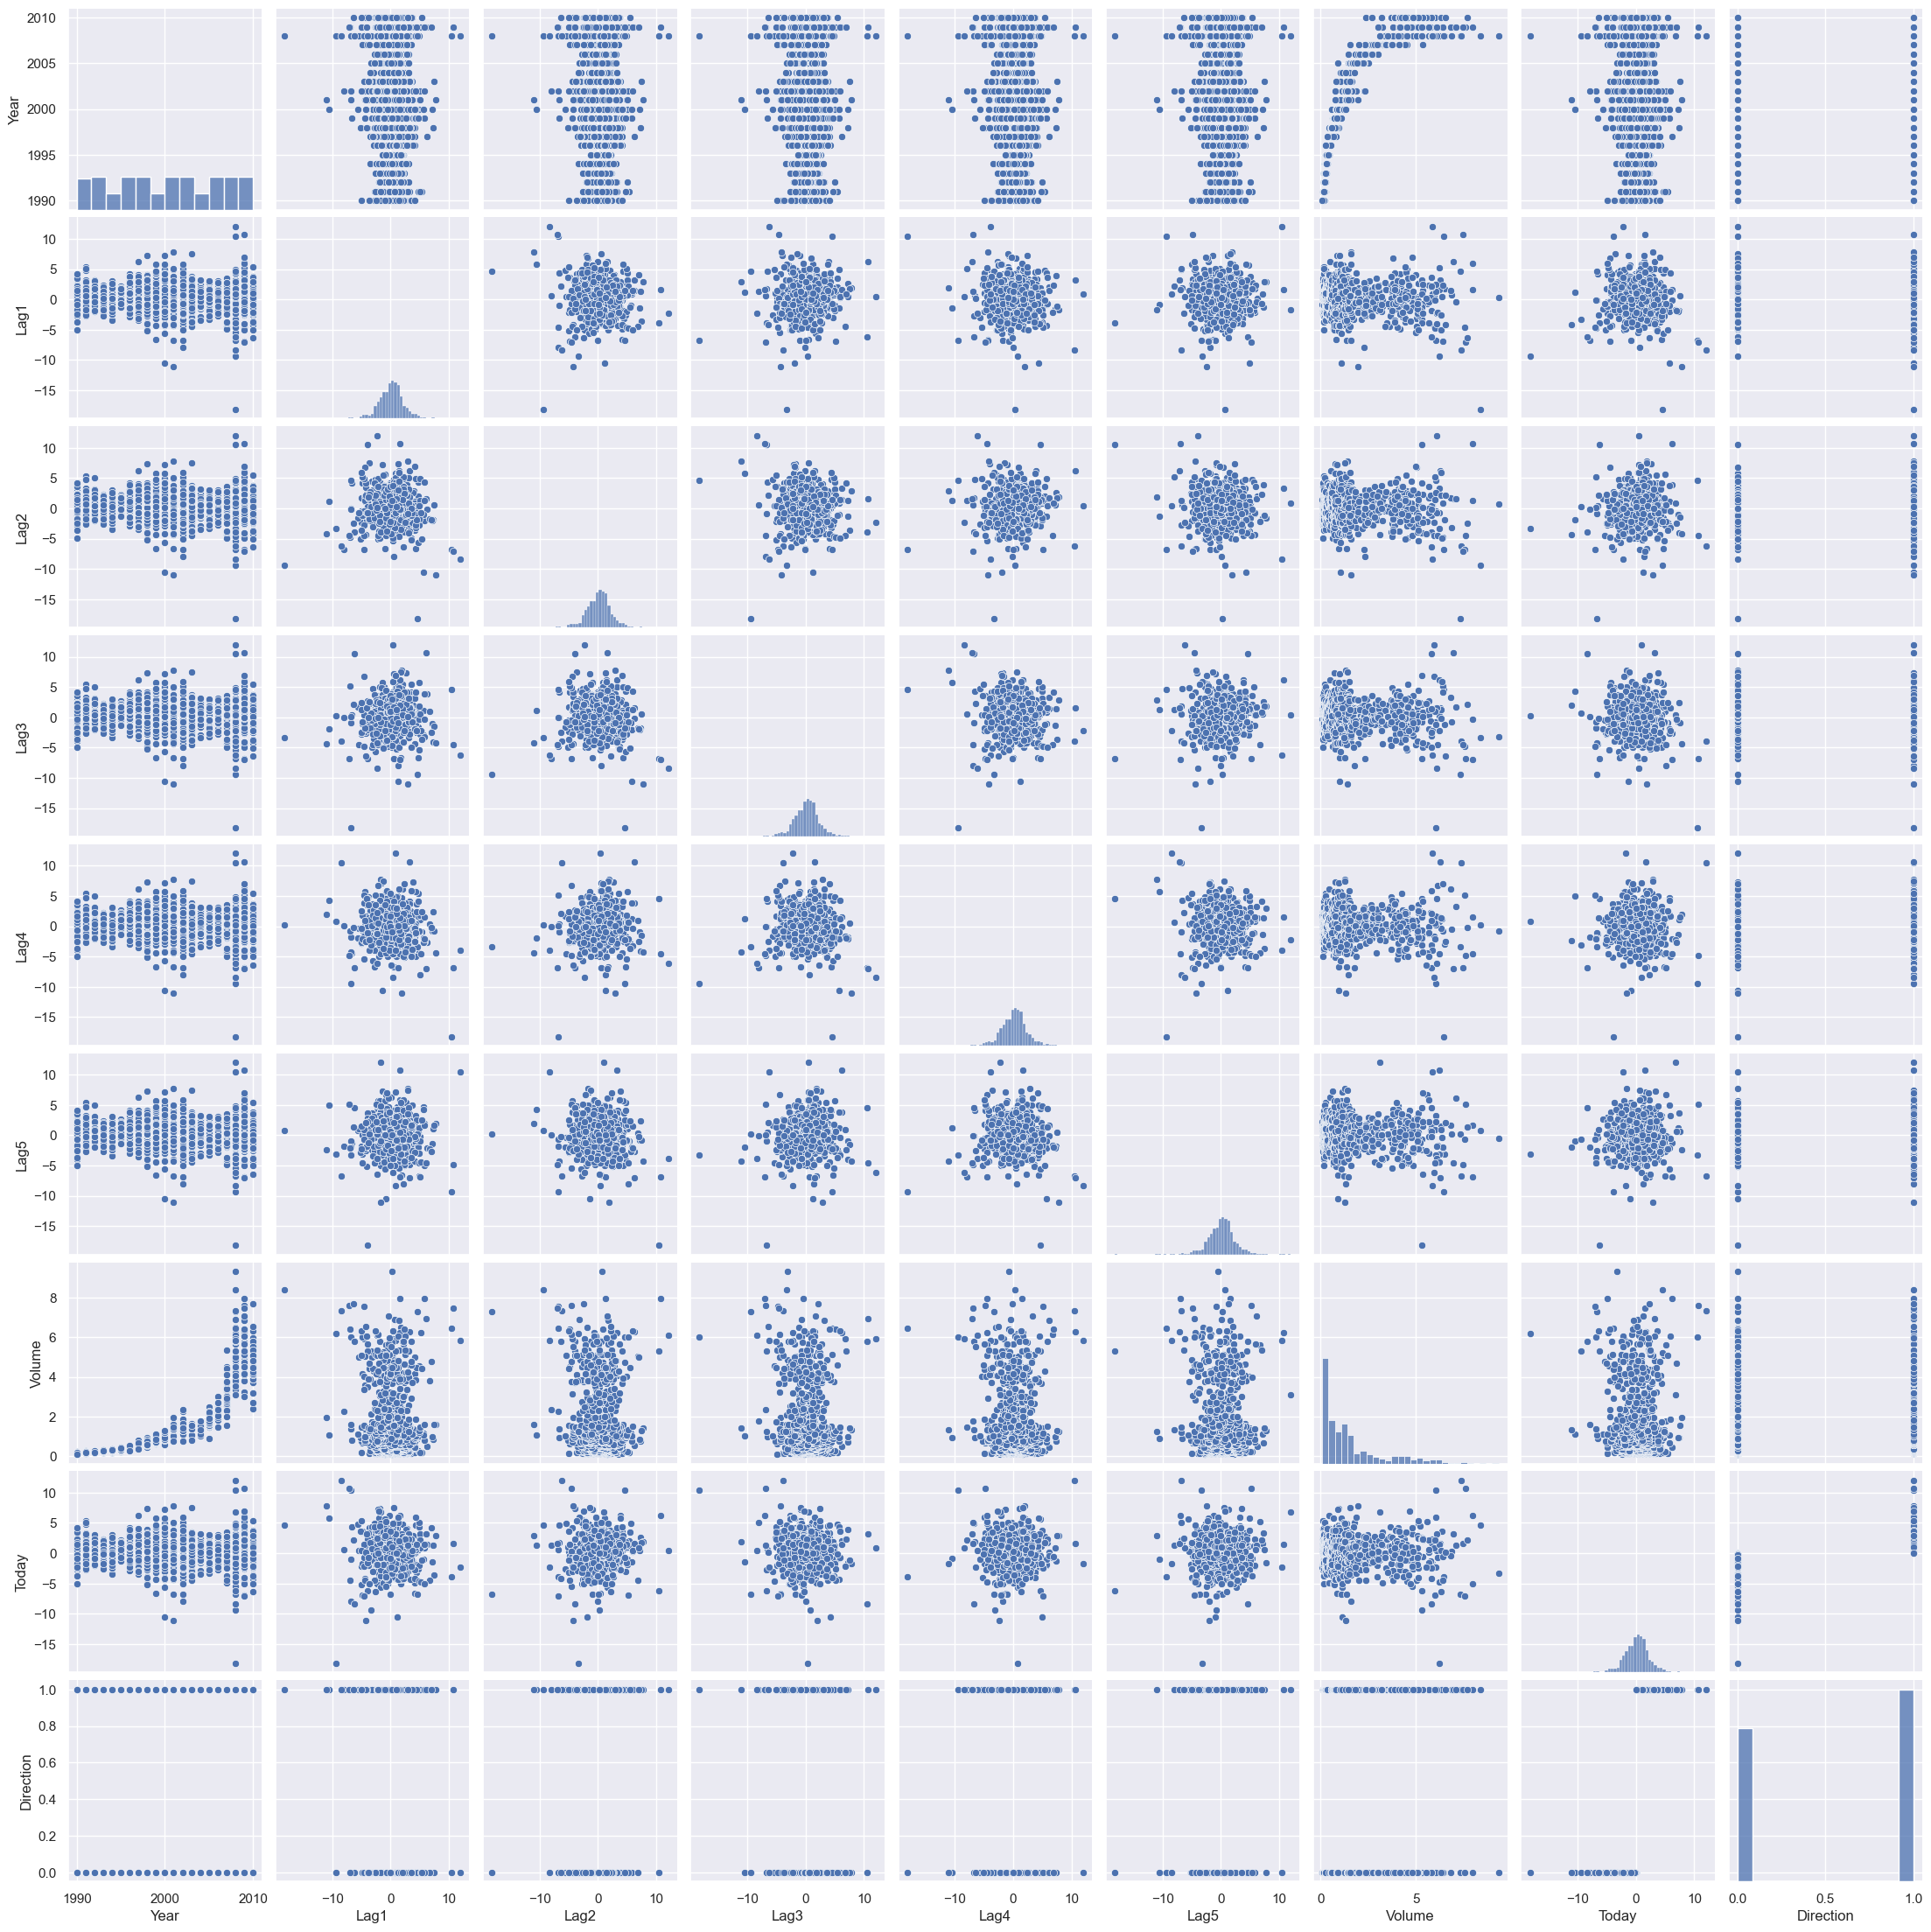

In [25]:
# BEGIN SOLUTION
sns.pairplot(df)
# END SOLUTION

**1. The graph between 'Volume' and 'Year' seems to be an exponential curve.**

**2. The graph between 'Direction' and 'Today' seems to be s-shaped. This suggests that there is a logistic relation between them.**

You can refer to the `seaborn` library documentation to attempt this problem: https://seaborn.pydata.org/

#### b) Use the full data set to perform a logistic regression with Direction as the response and the five `lag` variables plus `Volume` as predictors. Use the summary function to print the results. Do any of the predictors appear to be statistically significant? If so, which ones? Use the statsmodels to construct the classifier.

Link: https://www.statsmodels.org/

In [26]:
#BEGIN SOLUTION
X_b = df[['Lag1','Lag2','Lag3','Lag4','Lag5','Volume']]
y_b = df['Direction']
X_b = sm.add_constant(X_b)
# END SOLUTION

In [27]:
# BEGIN SOLUTION
logit_model = sm.Logit(y_b,X_b).fit()
print(logit_model.summary())
# END SOLUTION

Optimization terminated successfully.
         Current function value: 0.682441
         Iterations 4
                           Logit Regression Results                           
Dep. Variable:              Direction   No. Observations:                 1089
Model:                          Logit   Df Residuals:                     1082
Method:                           MLE   Df Model:                            6
Date:                Tue, 16 Apr 2024   Pseudo R-squ.:                0.006580
Time:                        23:40:32   Log-Likelihood:                -743.18
converged:                       True   LL-Null:                       -748.10
Covariance Type:            nonrobust   LLR p-value:                    0.1313
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.2669      0.086      3.106      0.002       0.098       0.435
Lag1          -0.0413      0.

**There is a statistically significant relationship between the predictor 'Lag2' and response 'Direction'. It is evident from p-value(0.03) being less than the threshold(0.05).**

#### C) Compute the confusion matrix and overall fraction of correct predictions. Explain what the confusion matrix is telling you about the types of mistakes made by logistic regression.

Confusion matrix =
 [[ 54 430]
 [ 48 557]]
Overall fraction of correct predictions = 0.5610651974288338


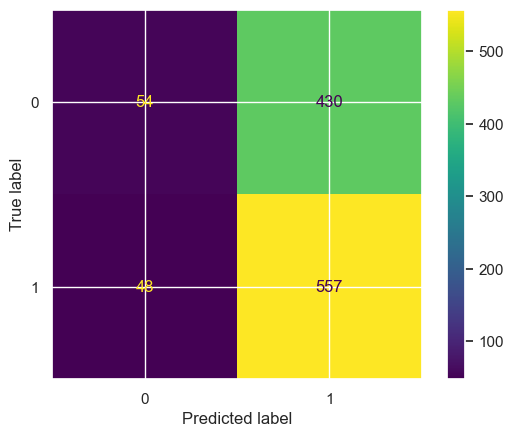

In [28]:
# BEGIN SOLUTION
predictions  = np.where(logit_model.predict(X_b)>0.5,1,0) # threshold = 0.5
conf_mat = confusion_matrix(df['Direction'],predictions)
frac_of_corpred = accuracy_score(df['Direction'], predictions)
print('Confusion matrix =\n',conf_mat)
ConfusionMatrixDisplay.from_predictions(df['Direction'],predictions)
print('Overall fraction of correct predictions = {}'.format(frac_of_corpred))
# END SOLUTION

In [29]:
# BEGIN SOLUTION

true_positive = conf_mat[1,1]
false_positive = conf_mat[0,1]
false_negative = conf_mat[1,0]
true_negative = conf_mat[0,0]

precision = true_positive/(true_positive+false_positive)
tpr = recall = true_positive/(true_positive+false_negative)
tnr = true_negative/(true_negative+false_positive)
fpr = false_positive/(false_positive+true_negative)
fnr = false_negative/(false_negative+true_positive)

print(f'Accuracy = {round(frac_of_corpred,3)}\n')
print(f'Precision = {round(precision,3)}\n')
print(f'True Positive Rate = Recall = {round(tpr,3)}\n')
print(f'True Negative Rate = {round(tnr,3)}\n')
print(f'False Positive Rate = {round(fpr,3)}\n')
print(f'False Negative Rate = {round(fnr,3)}\n')

# END SOLUTION

Accuracy = 0.561

Precision = 0.564

True Positive Rate = Recall = 0.921

True Negative Rate = 0.112

False Positive Rate = 0.888

False Negative Rate = 0.079



**Observations:**

1. At 0.5 threshold, the TPR and FPR are both high. Apart from predicting large number of true positives the model is predicting more number of false positives as well.

2. The model predicted 56.1% of the predictions correctly.

3. It has a recall or true positive rate of 92.1% which indicates that out of the total actual positive('Up' or 1) observations the model predicted 92.1% as positives. 

4. But it also has a false positive rate of 88.8% which indicates that out of the total actual negative('Down') observations the model predicted 88.8% as positives which is undesirable.

5. Finally, out of the total acutal negative('Down') observations the model predicted only 11.2% as negatives. So, the true negative rate is 11.2%.

6. There are very few false negatives that is out of the total actual positives, the model predicted only 7.9% as negatives which is actually good.

7. Finally, this model can be used to predict when the stock price goes up provided we reduce the false positive rate by adjusting the threshold.

#### d) Now fit the logistic regression model using a training data period from __1990 to 2008__, with `Lag2` as the only predictor. Compute the confusion matrix and the overall fraction of correct predictions for the held out data (that is, the data from __2009 and 2010__).

In [ ]:
# BEGIN SOLUTION


# END SOLUTION

In [ ]:
# BEGIN SOLUTION
# END SOLUTION

In [ ]:
#BEGIN SOLUTION


#END SOLUTION

#### e)Repeat (d) using LDA.

In [ ]:
# BEGIN SOLUTION


# END SOLUTION

In [ ]:
# BEGIN SOLUTION


# END SOLUTION


In [ ]:
# BEGIN SOLUTION
# END SOLUTION

#### f) Repeat (d) using QDA.

In [ ]:
# BEGIN SOLUTION


# END SOLUTION

In [ ]:
# BEGIN SOLUTION
# END SOLUTION

In [ ]:
# BEGIN SOLUTION
# END SOLUTION

#### g) Repeat (d) using KNN with K=1

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION
# END SOLUTION

#### h) Which of these methods appears to provide the best results on this data?


Answer: Provide your answer in this Markdown cell

### 5) Develop a model to predict whether a given car gets high or low gas mileage based on the `Auto` data set. Load the dataset:

In [ ]:
# BEGIN SOLUTION
#Load dataset

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

a) Create a binary variable, `mpg01`, that contains a `1` if `mpg` contains a value above its median, and a `0` if `mpg` contains a value below its median.Note : you may find it helpful to use the `pd.DataFrame()` function to create a single data set containing both `mpg01` and the other `Auto` variables.

Link to median():
https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.median.html


In [ ]:
# BEGIN SOLUTION


# END SOLUTION

#### b) Explore the data graphically in order to investigate the association between `mpg01` and the other features. Which of the other features seem most likely to be useful in predicting `mpg01`? Scatterplots and boxplots may be useful tools to answer this question Describe your findings

Link to Scatter plot: https://seaborn.pydata.org/generated/seaborn.scatterplot.html

Link to Violin plot: https://seaborn.pydata.org/generated/seaborn.violinplot.html

Link to Box plot: https://seaborn.pydata.org/generated/seaborn.boxplot.html

In [ ]:
# BEGIN SOLUTION


# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

#### C) Split the data into a training set and a test set (70%, 30%). Use `random.seed(4)` to make the training data reproducible.

Link to linear model: https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html

In [ ]:
# BEGIN SOLUTION


# END SOLUTION

#### d) Perform LDA on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in (b). What is the test error of the model obtained?



In [ ]:
# BEGIN SOLUTION


# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

#### e) Perform QDA on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in (b). What is the test error of the model obtained?


In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
 # BEGIN SOLUTION



# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

#### f) Perform logistic regression on the training data in order to predict `mpg01` using the variables that seemed most associated with `mpg01` in (b). What is the test error of the model obtained?

Link to linear model: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html


In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION

In [ ]:
# BEGIN SOLUTION

# END SOLUTION